In [22]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [14]:
import pandas as pd

# 1. Load the Core Logistics Data
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')

# 2. Build the Master DataFrame (INNER JOINS)
# Merge items to their orders
df = pd.merge(df_orders, df_items, on='order_id', how='inner')

# Merge the customer destination data
df = pd.merge(df, df_customers, on='customer_id', how='inner')

# Merge the product dimension data
df = pd.merge(df, df_products, on='product_id', how='inner')

df.head(10)



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,sao goncalo do amarante,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,santo andre,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1,060cb19345d90064d1015407193c233d,...,congonhinhas,PR,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1,a1804276d9941ac0733cfd409f5206eb,...,santa rosa,RS,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1,4520766ec412348b8d4caa5e8a18c464,...,nilopolis,RJ,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1,ac1789e492dcd698c5c10b97a671243a,...,faxinalzinho,RS,moveis_decoracao,41.0,432.0,2.0,300.0,35.0,35.0,15.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1,9a78fb9862b10749a117f7fc3c31f051,...,sorocaba,SP,moveis_escritorio,45.0,527.0,1.0,9750.0,42.0,41.0,42.0


In [19]:
print('Step 1')

print("\nShape of the data set ")
df.shape
print(f'Dataset shape is {df.shape}')

print("\n Data types ")
df.dtypes
print(f'Dataset data types \n{df.dtypes}')


Step 1

Shape of the data set 
Dataset shape is (112650, 26)

 Data types 
Dataset data types 
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
order_item_id                      int64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
product_category_name                str
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
pro

In [18]:
print("\n Total null values")

df.isnull().sum()
print(f'Null values are \n{df.isnull().sum()}')



 Total null values
Null values are 
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width

In [20]:

print(f'\n Duplicate Data')
print(f'Duplicate data are \n{df.duplicated().sum()}')


 Duplicate Data
Duplicate data are 
0


In [21]:

df = df.dropna(subset=[
    'order_delivered_customer_date', 
    'order_delivered_carrier_date', 
    'order_approved_at',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])

# 2. Fill the non-fatal nulls (Missing text labels)
df['product_category_name'] = df['product_category_name'].fillna('Unknown')

# 3. Convert all text dates to Pandas datetime objects
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# 4. Calculate the Business Metric: Delivery Delay
# Positive number = LATE. Negative number = EARLY.
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# 5. Sanity Check the New Engine
print(f"Cleaned Dataset Shape: {df.shape}")
print("\n--- Delivery Delay Statistics ---")
print(df['delivery_delay_days'].describe())

Cleaned Dataset Shape: (110162, 27)

--- Delivery Delay Statistics ---
count    110162.000000
mean        -12.028295
std          10.160136
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64


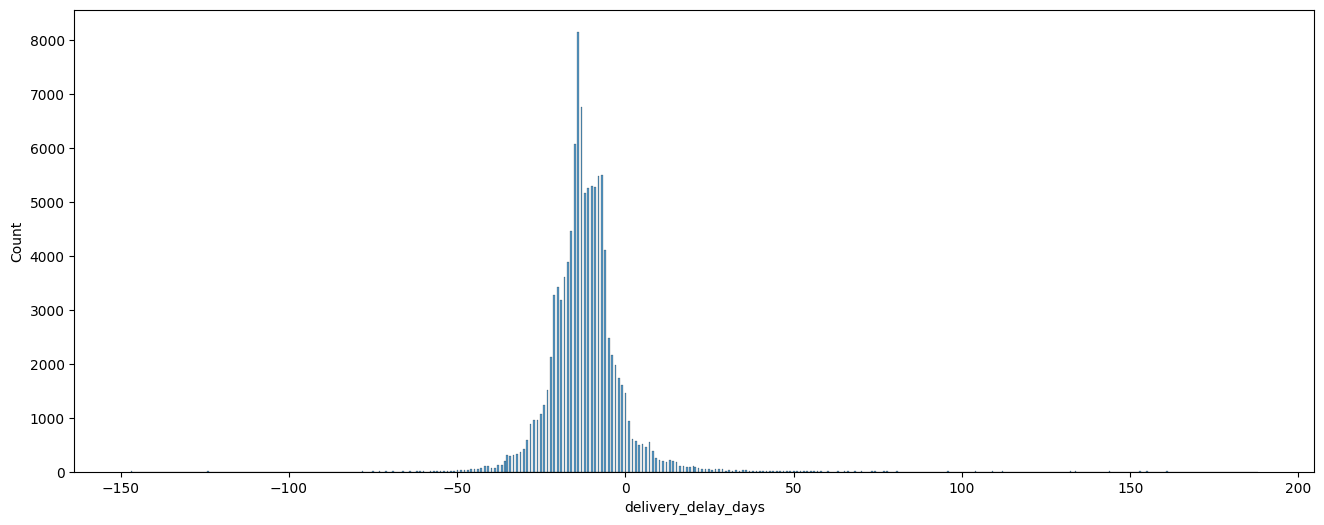

In [23]:
plt.figure(figsize=(16,6))
sns.histplot(data=df["delivery_delay_days"])
plt.show()

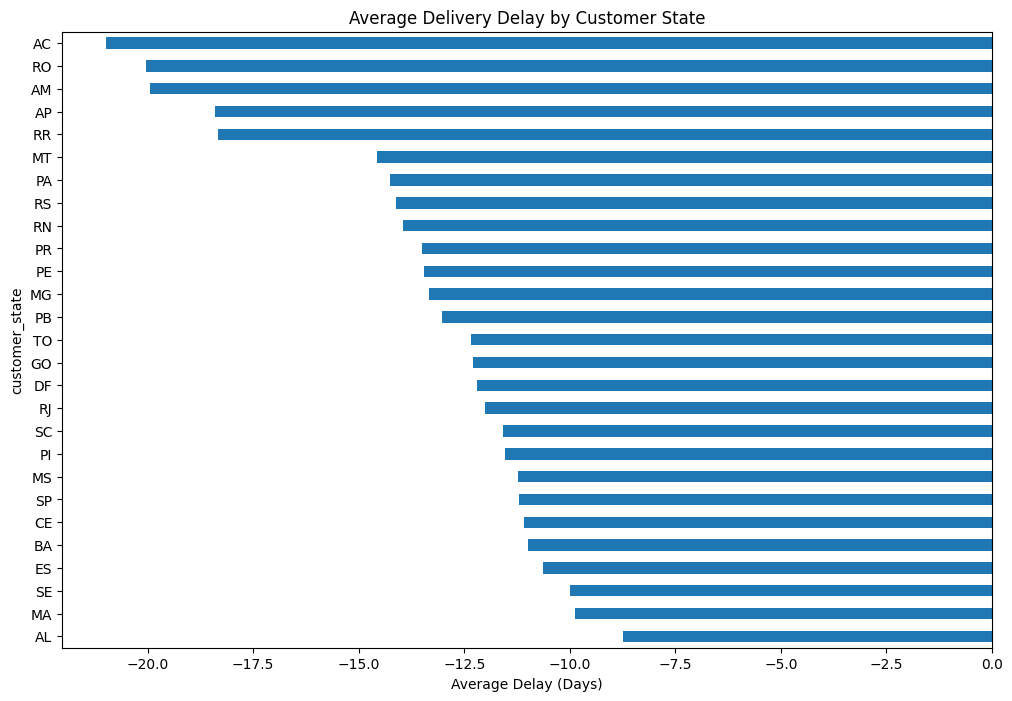

In [25]:
plt.figure(figsize=(12, 8))
# Group by state and calculate mean delay
state_delays = df.groupby('customer_state')['delivery_delay_days'].mean().sort_values(ascending=False)
state_delays.plot(kind='barh')
plt.title('Average Delivery Delay by Customer State')
plt.xlabel('Average Delay (Days)')
plt.show()

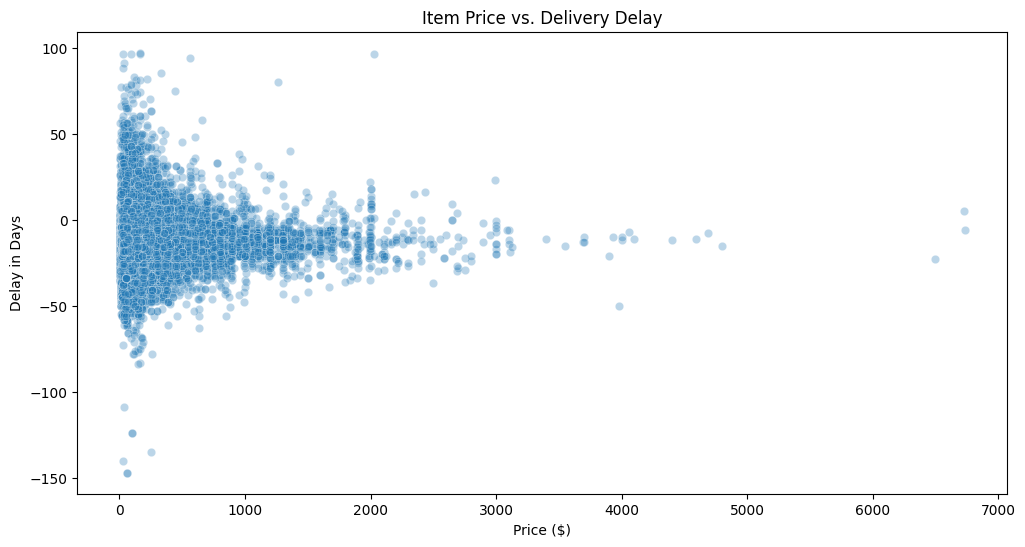

In [26]:
plt.figure(figsize=(12, 6))
# Filter out the extreme outliers (e.g., > 100 days) so we can actually see the trend
df_filtered = df[df['delivery_delay_days'] < 100]

sns.scatterplot(data=df_filtered, x='price', y='delivery_delay_days', alpha=0.3)
plt.title('Item Price vs. Delivery Delay')
plt.xlabel('Price ($)')
plt.ylabel('Delay in Days')
plt.show()

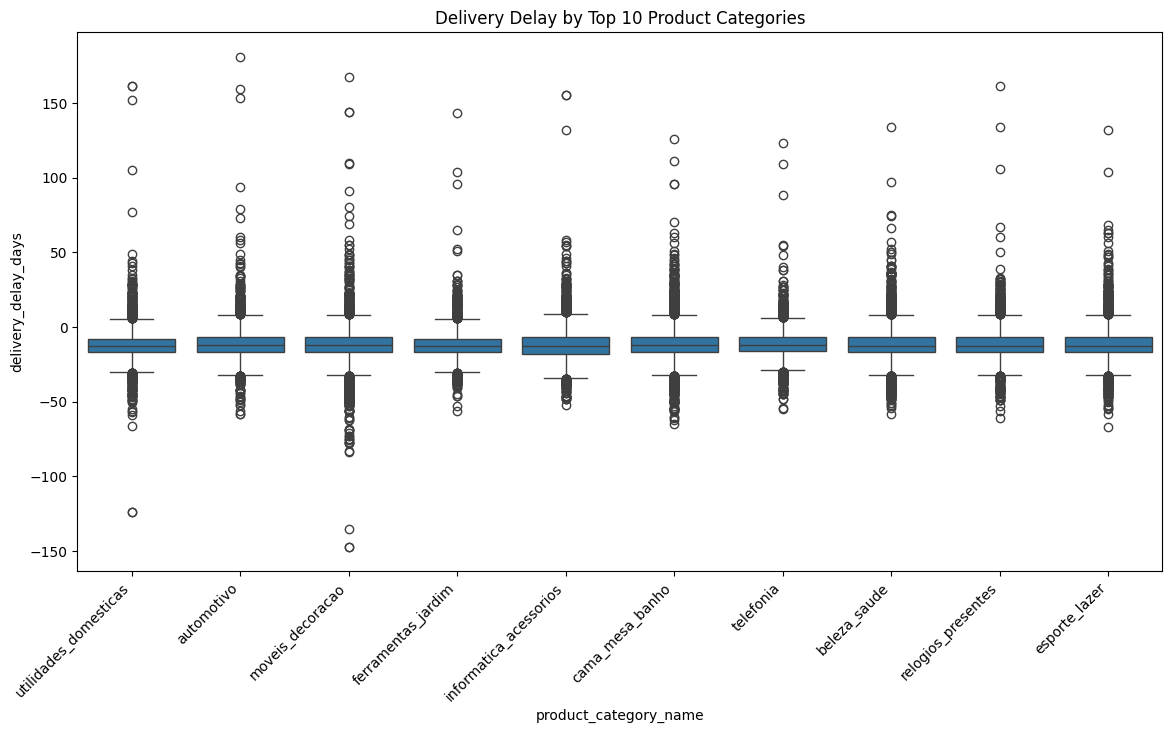

In [27]:
# Get the top 10 categories by volume
top_categories = df['product_category_name'].value_counts().nlargest(10).index

# Filter the dataframe
df_top_cats = df[df['product_category_name'].isin(top_categories)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_cats, x='product_category_name', y='delivery_delay_days')
plt.xticks(rotation=45, ha='right') # Rotate labels so they are readable
plt.title('Delivery Delay by Top 10 Product Categories')
plt.show()

In [ ]:
# Ensure the purchase timestamp is available for time-based analysis
if 'order_purchase_timestamp' not in df.columns:
    df = df.merge(df_orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')

# Convert to datetime if not already
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Resample by month and take the mean delay
df.set_index('order_purchase_timestamp', inplace=True)
monthly_delay = df['delivery_delay_days'].resample('ME').mean()

plt.figure(figsize=(14, 6))
monthly_delay.plot(marker='o')
plt.title('Average Delivery Delay Trend Over Time')
plt.ylabel('Average Delay (Days)')
plt.grid(True)
plt.show()

KeyError: 'order_purchase_timestamp'